<a href="https://colab.research.google.com/github/BhaveshJoshi934/RTR2020/blob/master/RegressionAndHyperPlane.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7,5)
NAVY = "#004BA0"
GOLD = "#D1AB3E"

In [66]:
df = pd.read_csv("IPLPlayerStat.csv")
if "Unnamed: 0" in df.columns:
  df = df.drop(columns=["Unnamed: 0"])
print(df.shape)
df.head()

(605, 16)


,player,runs,boundaries,balls_faced,wickets,balls_bowled,runs_conceded,matches,batting_avg,batting_strike_rate,boundaries_percent,bowling_economy,bowling_avg,bowling_strike_rate,catches,stumpings
0,A Ashish Reddy,280,31,196,18.0,270.0,400.0,28,10.00,142.86,15.82,8.89,22.22,15.00,8.0,0.0
1,A Badoni,161,18,139,2.0,12.0,12.0,11,14.64,115.83,12.95,6.00,6.00,6.00,8.0,0.0
2,A Chandila,4,0,7,11.0,234.0,245.0,12,0.33,57.14,0.00,6.28,22.27,21.27,2.0,0.0
3,A Chopra,53,7,75,0.0,0.0,0.0,6,8.83,70.67,9.33,0.00,0.00,0.00,2.0,0.0
4,A Choudhary,25,2,20,5.0,108.0,144.0,5,5.00,125.00,10.00,8.00,28.80,21.60,0.0,0.0


In [67]:
df["balls_faced"].describe()

,balls_faced
count,605.000000
mean,373.477686
std,764.432561
min,1.000000
25%,18.000000
50%,73.000000
75%,285.000000
max,5266.000000


In [68]:
print(df.isna().sum())

player                 0
runs                   0
boundaries             0
balls_faced            0
wickets                0
balls_bowled           0
runs_conceded          0
matches                0
batting_avg            0
batting_strike_rate    0
boundaries_percent     0
bowling_economy        0
bowling_avg            0
bowling_strike_rate    0
catches                0
stumpings              0
dtype: int64


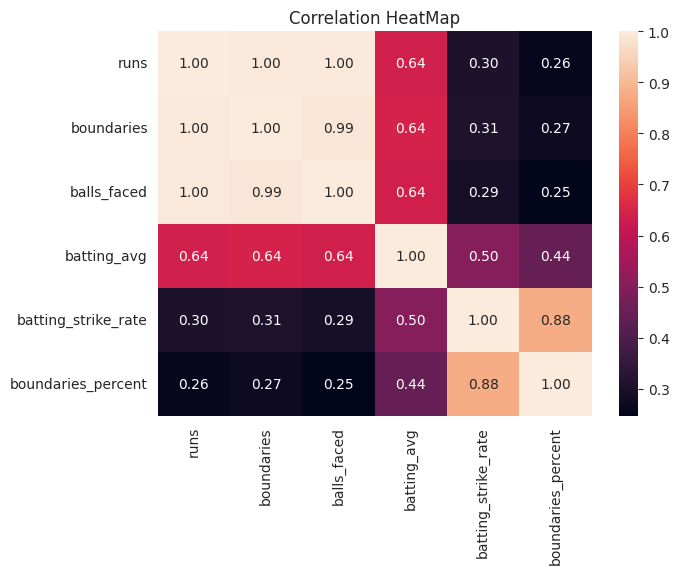

In [69]:
cols = ["runs", "boundaries", "balls_faced", "batting_avg", "batting_strike_rate", "boundaries_percent"]

plt.figure(figsize=(7,5))
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f")
plt.title("Correlation HeatMap")
plt.show()

In [70]:
X = df[["balls_faced"]]
y = df["runs"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", round(model.intercept_, 2))
print("Coefficients:", round(model.coef_[0], 2))
print(f"\nMeaning: Every extra balls faced adds ~{model.coef_[0]:.2f} runs on average")

Intercept: -15.33
Coefficients: 1.28

Meaning: Every extra balls faced adds ~1.28 runs on average


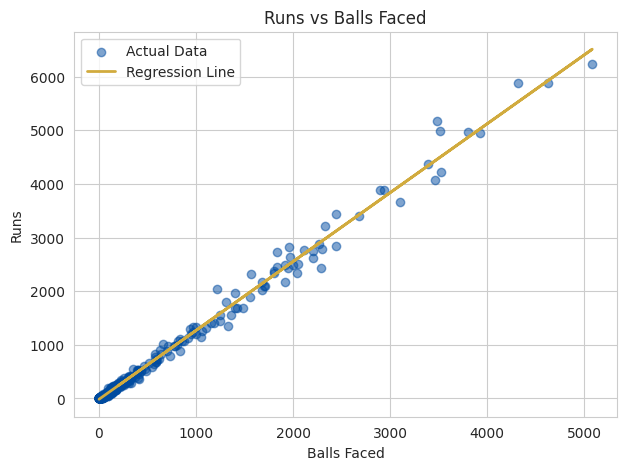

In [71]:
plt.figure(figsize=(7,5))
plt.scatter(X_train, y_train, color = NAVY, alpha = 0.5, label = "Actual Data")
plt.plot(X_train, model.predict(X_train), color = GOLD, linewidth=2, label = "Regression Line")
plt.title("Runs vs Balls Faced")
plt.xlabel("Balls Faced")
plt.ylabel("Runs")
plt.legend()
plt.show()

In [72]:
y_model_predict = model.predict(X_test)
pd.DataFrame({
    "balls_faced": X_test["balls_faced"].values[:4],
    "Actual runs": y_test.values[:4],
    "Predicted runs": np.round(y_model_predict[:4], 1)
})

,balls_faced,Actual runs,Predicted runs
0,434,522,542.1
1,27,40,19.3
2,57,76,57.9
3,31,21,24.5


In [73]:
new_player = pd.DataFrame({"balls_faced":[100,200,300]})
new_preds = model.predict(new_player)
for balls, runs in zip(new_player["balls_faced"], new_preds):
  print(f"Balls faced = {balls} -> Predicted_runs = {runs:.0f}")

Balls faced = 100 -> Predicted_runs = 113
Balls faced = 200 -> Predicted_runs = 242
Balls faced = 300 -> Predicted_runs = 370


In [74]:
features = ["balls_faced", "boundaries"]

X = df[features]
y = df["runs"]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train_m, y_train_m)

print("Intercept:", round(model.intercept_, 2))
for f,c in zip(features, model.coef_):
  print(f"Coefficient for {f}: {c:.4f}")

Intercept: -3.83
Coefficient for balls_faced: 0.6870
Coefficient for boundaries: 3.5314


In [76]:
y_pred = model.predict(X_test_m)
pd.DataFrame({
    "Actual Runs": y_test_m.values[:5],
    "Predicted Runs": np.round(y_pred[:5], 1)
    })

,Actual Runs,Predicted Runs
0,522,513.3
1,40,35.9
2,76,70.6
3,21,24.5
4,663,650.9


In [80]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

intercept = -3.83

coef = {
    "balls_faced":0.6870,
    "boundaries": 3.5314
}

def predict(balls_faced, boundaries):
  return intercept + coef["balls_faced"]*balls_faced + coef["boundaries"]*boundaries

x_feature = "balls_faced"
y_feature = "boundaries"

x = np.linspace(df[x_feature].min(), df[x_feature].max(), 50)
y = np.linspace(df[y_feature].min(), df[y_feature].max(), 50)

X_plane, Y_plane = np.meshgrid(x,y)

Z_plane = predict(X_plane, Y_plane)

df["Predicted"] = predict(df["balls_faced"], df["boundaries"])

fig = go.Figure()

fig.add_trace(go.Surface(
    x = X_plane,
    y = Y_plane,
    z = Z_plane,
    colorscale = "Viridis",
    opacity=0.75,
    name="Regression Surface",
    showscale=True
))

fig.add_trace(go.Scatter3d(
    x = df[x_feature],
    y = df[y_feature],
    z = df["Predicted"],
    mode = "markers",
    marker=dict(
        size=5,
        color="red"
    ),
    text = df["player"],
    hovertemplate=
    "<b>%{text}</b><br>" +
    f"{x_feature.replace('_', ' ').title()}: %{{x:.2f}}<br>" +
    f"{y_feature.replace('_', ' ').title()}: %{{y}}<br>" +
    "Prediction: %{z:.2f}<extra></extra>",
    name="Players"
))

fig.update_layout(
    title="Multiple Linear Regression Prediction Surface",
    scene=dict(
        xaxis_title=x_feature.replace("_", " ").title(),
        yaxis_title=y_feature.replace("_", " ").title(),
        zaxis_title="Predicted Value"
    ),
    width=1000,
    height=750
)
fig.show()

In [81]:
def adjusted_r2(r2, n, p):
  return 1 - (1 - r2) * (n - 1) / (n - p - 1)

def evaluate(name, y_true, y_pred, n_features):
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = root_mean_squared_error(y_true, y_pred)
  r2 = r2_score(y_true, y_pred)
  adj_r2 = adjusted_r2(r2, len(y_true), n_features)

  print(f"---- {name} ----")
  print(f"MAE: {mae:.2f}")
  print(f"MSE: {mse:.2f}")
  print(f"RMSE: {rmse:.2f}")
  print(f"R2: {r2:.2f}")
  print(f"Adjusted R2: {adj_r2:.4f}\n")

  return {"model":name, "mae":mae, "mse":mse, "rmse":rmse, "r2":r2, "adj_r2":adj_r2}

results = []
results.append(evaluate("Linear Regression", y_test, y_model_predict, 1))
results.append(evaluate("Multiple Linear Regression", y_test_m, y_pred,n_features=14))

---- Linear Regression ----
MAE: 33.81
MSE: 3246.97
RMSE: 56.98
R2: 1.00
Adjusted R2: 0.9967

---- Multiple Linear Regression ----
MAE: 18.08
MSE: 1450.77
RMSE: 38.09
R2: 1.00
Adjusted R2: 0.9984

